Steps -

0. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Train test split
3. Scale the values
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

In [54]:
import numpy as np
import pandas as pd

In [55]:
df = pd.read_csv('/content/placement.csv')
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [56]:
df.info   # it gives the complete information about the data.

<bound method DataFrame.info of     Unnamed: 0  cgpa     iq  placement
0            0   6.8  123.0          1
1            1   5.9  106.0          0
2            2   5.3  121.0          0
3            3   7.4  132.0          1
4            4   5.8  142.0          0
..         ...   ...    ...        ...
95          95   4.3  200.0          0
96          96   4.4   42.0          0
97          97   6.7  182.0          1
98          98   6.3  103.0          1
99          99   6.2  113.0          1

[100 rows x 4 columns]>

In [57]:
df.shape

(100, 4)

#0.1 Preprocessing

In [58]:
df = df.iloc[:,1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


#0.2 Exploratory Data Analysis (EDA)

In [59]:
import matplotlib.pyplot as plt

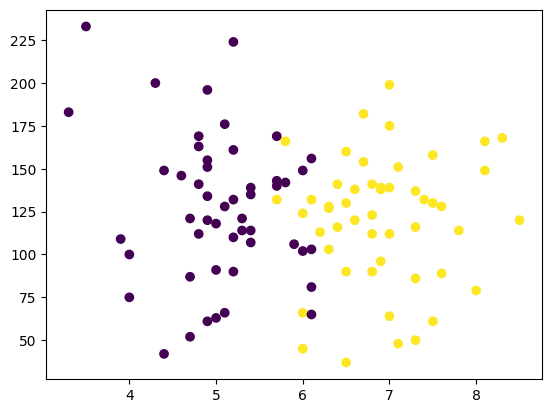

In [60]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])
plt.show()

#0.3 Feature Selection

In [61]:
# we avoid this step in this particular project because we don't have any unnecessary column of data.

#1. Extract Input and Output Columns

In [62]:
x = df.iloc[:,:2] #independent Variable
y = df.iloc[:,-1] # Dependent Variable

#2. Train-Test Split Data

In [63]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size=0.1)

In [64]:
X_train

,cgpa,iq
63,6.3,128.0
26,7.0,199.0
88,4.4,149.0
86,5.1,128.0
97,6.7,182.0
...,...,...
73,4.9,61.0
92,5.2,110.0
42,7.6,89.0
3,7.4,132.0


In [65]:
Y_train

,placement
63,1
26,1
88,0
86,0
97,1
...,...
73,0
92,0
42,1
3,1


In [66]:
X_test

,cgpa,iq
75,4.8,169.0
91,7.5,158.0
48,6.6,138.0
44,7.5,61.0
62,6.0,102.0
61,7.3,137.0
85,5.8,166.0
59,4.8,112.0
64,7.0,64.0
93,6.8,112.0


In [67]:
Y_test

,placement
75,0
91,1
48,1
44,1
62,0
61,1
85,1
59,0
64,1
93,1


#3. Scale the values
It normalizes or standardizes the range of independent variables (features), ensuring they are on a similar scale

In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train

array([[ 0.31038426,  0.1057159 ],
       [ 0.92145327,  1.87874634],
       [-1.34823163,  0.63013336],
       [-0.73716262,  0.1057159 ],
       [ 0.65956655,  1.45421793],
       [ 0.31038426,  0.08074364],
       [ 1.00874884, -1.89206488],
       [ 0.39767983, -0.19395122],
       [-0.91175376,  0.68007787],
       [ 0.48497541, -0.84322997],
       [ 0.74686212,  0.43035528],
       [ 0.48497541, -2.16675974],
       [-0.12609361,  0.45532754],
       [ 0.92145327,  0.38041076],
       [-0.64986704,  2.50305284],
       [-1.08634491, -0.91814675],
       [-0.4752759 ,  0.38041076],
       [ 0.04849754, -1.44256421],
       [ 0.74686212, -0.0191454 ],
       [-0.21338918,  0.20560494],
       [ 0.22308869, -0.268868  ],
       [-0.91175376,  0.25554946],
       [-0.82445819, -1.51748099],
       [-0.4752759 , -0.41870156],
       [ 0.13579311, -1.46753647],
       [-1.4355272 ,  1.9037186 ],
       [ 0.8341577 ,  0.38041076],
       [ 0.13579311, -1.06798031],
       [-0.73716262,

In [69]:

X_train.shape

(90, 2)

In [70]:
X_test = scaler.transform(X_test)
X_test

array([[-0.99904934,  1.12957855],
       [ 1.35793114,  0.85488369],
       [ 0.57227098,  0.3554385 ],
       [ 1.35793114, -1.56742551],
       [ 0.04849754, -0.54356285],
       [ 1.18333999,  0.33046624],
       [-0.12609361,  1.05466177],
       [-0.99904934, -0.29384026],
       [ 0.92145327, -1.49250873],
       [ 0.74686212, -0.29384026]])

#4. Train the model

In [72]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train, Y_train)

LogisticRegression()

In [73]:
Y_Pred = clf.predict(X_test)

In [74]:
Y_test

,placement
75,0
91,1
48,1
44,1
62,0
61,1
85,1
59,0
64,1
93,1


#5. Evaluate the model and Model Selection

In [75]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,Y_Pred)

0.8

<Axes: >

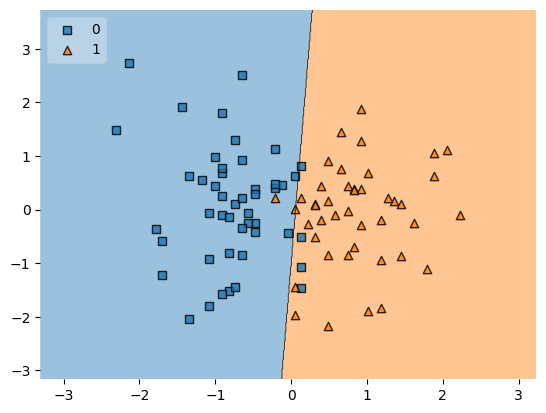

In [77]:
# implementing decision boundry for understanding the pattern of our model
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, Y_train.values, clf=clf, legend=2)

#6. Deploying the mode

In [80]:
import pickle
pickle.dump(clf, open('model.pkl','wb'))